# Genesis robot tutorial

This notebook demonstrates how to create and run a simple robot simulation in the Genesis backend using RobotBlockSet.

The workflow is:

- import Genesis and RobotBlockSet interfaces
- create a Genesis scene from an MJCF model
- add a Panda robot entity to the scene
- execute a short Cartesian and joint motion sequence
- capture robot states during motion
- plot measured and commanded joint/task trajectories

This notebook is therefore a Genesis integration example, not a camera-calibration tutorial.

In [1]:
import time
import numpy as np
import math

import matplotlib.pyplot as plt

from robotblockset.tools import get_rbs_path

import genesis as gs
from robotblockset.genesis.robots_genesis import panda as panda_genesis

np.set_printoptions(precision=3, suppress=True, linewidth=100)

## Helper function for capturing robot states

The following function stores robot time, joint states, task-space states, and commanded references during motion. These recorded arrays are later used for plotting.

Capture measured and commanded robot states into global arrays for later plotting.


In [2]:
it = 0
def CaptureRobot(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
    it += 1

MJCF model used to construct the Genesis scene.


In [3]:
SCENE_PATH = get_rbs_path() + "/mujoco/mjcf_models/panda_scene.xml"
SHOW_VIEWER = True

# Initialize Genesis

Initialize the Genesis backend once before creating any scene or entities.

Initialize Genesis with GPU backend and reduced logging noise.


In [4]:
gs.init(backend=gs.gpu, logging_level="warning")

# Create Genesis scene

A Genesis scene defines simulation timing, viewer settings, and the set of physical entities that will be simulated.

## Define scene

Here we configure the viewer camera and simulation timestep.

Create the Genesis scene object.


In [5]:
scene = gs.Scene(
    viewer_options=gs.options.ViewerOptions(
        camera_pos=(0, -3.5, 2.5),
        camera_lookat=(0.0, 0.0, 0.5),
        camera_fov=30,
        res=(960, 640),
        max_FPS=60,
    ),
    sim_options=gs.options.SimOptions(
        dt=0.002,      ),
    show_viewer=SHOW_VIEWER,
)

## Add entities

The robot is added from an MJCF model file. This allows the same robot description to be reused in different simulation backends.

Add the Panda robot model to the Genesis scene.


In [6]:
franka = scene.add_entity(
    gs.morphs.MJCF(
        file=SCENE_PATH,
    ),
)

[Genesis] [17:58:02] [WARNING] (MJCF) Approximating tendon by joint actuator for `panda_finger_joint1`
[Genesis] [17:58:02] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `panda_finger_joint1`.
[Genesis] [17:58:02] [WARNING] (MJCF) Approximating tendon by joint actuator for `panda_finger_joint2`
[Genesis] [17:58:02] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `panda_finger_joint2`.


d:\Leon\Python\RBS\.venv\Lib\site-packages\trimesh\triangles.py:302: RuntimeWarning: invalid value encountered in divide
  center_mass = integrated[1:4] / volume


## Build scene

Building finalizes the scene and allocates the simulation objects so the robot can be controlled.

Finalize the Genesis scene before creating the robot wrapper.


In [7]:
scene.build()

[Genesis] [17:58:04] [WARNING] Constraint solver time constant should be greater than 2*substep_dt. timeconst is changed from `0.002` to `0.004`). Decrease simulation timestep or increase timeconst to avoid altering the original value.
[Genesis] [17:58:04] [WARNING] Neutral robot position (qpos0) exceeds joint limits.
[Genesis] [17:58:08] [WARNING] Filtered out geometry pairs causing self-collision for the neutral configuration (qpos0): (6, 11), (7, 11), (14, 21), (15, 20), (16, 23), (17, 22). Consider tuning Morph option 'decompose_robot_error_threshold' or specify dedicated collision meshes. This behavior can be disabled by setting Morph option 'enable_neutral_collision=True'.


d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)
d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var MJ_GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)


## Create robot object

Wrap the Genesis entity with the RobotBlockSet `panda_genesis` interface so standard RobotBlockSet commands can be used.

Create the RobotBlockSet Genesis robot wrapper.


In [8]:
r = panda_genesis(scene=scene, robot_entity=franka, robot_name="panda")

[RBS_INFO] [1773421127.897860527] [panda_Genesis]: Robot connected to Genesis


# Move robot

The next cell resets the robot, starts state capture, executes a short Cartesian move followed by a joint move back home, and then stops the capture.

Execute a short motion sequence while logging robot states.


In [13]:
r.Restart(u=r.q_home)
r.Wait(2)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0, 0.2, -0.1], t=1)
r.Wait(1)
r.JMove(r.q_home, t=1)
r.Wait(1)
r.StopCapture()


Plot measured and commanded joint positions and velocities.


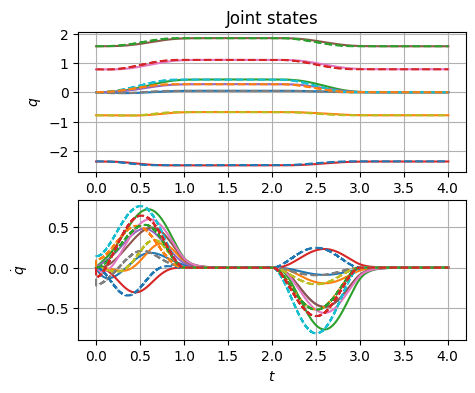

In [14]:
fig, ax = plt.subplots(2, 1, num=1, figsize=(5, 4))
ax[0].plot(tt, qt, "-")
ax[0].plot(tt, rqt, "--")
ax[0].grid()
ax[0].set_ylabel("$q$")
ax[0].set_title("Joint states")
ax[1].plot(tt, qdt, "-")
ax[1].plot(tt, rqdt, "--")
ax[1].grid()
ax[1].set_ylabel("$\\dot q$")
_ = ax[1].set_xlabel("$t$")

Plot measured and commanded task-space positions and linear velocities.


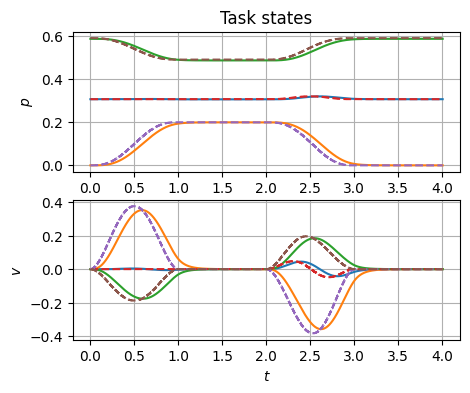

In [15]:
fig, ax = plt.subplots(2, 1, num=1, figsize=(5, 4))
ax[0].plot(tt, xt[:, :3], "-")
ax[0].plot(tt, rxt[:, :3], "--")
ax[0].grid()
ax[0].set_ylabel("$p$")
ax[0].set_title("Task states")
ax[1].plot(tt, vt[:, :3], "-")
ax[1].plot(tt, rvt[:, :3], "--")
ax[1].grid()
ax[1].set_ylabel("$v$")
_ = ax[1].set_xlabel("$t$")